In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/manufacturing_dataset_1000_samples.csv")

# Inspect first rows
print(df.head())

# Check column names
print(df.columns)

# Check data types
print(df.dtypes)

# Summary statistics
print(df.describe())

# Check missing values
print(df.isnull().sum())

          Timestamp  Injection_Temperature  Injection_Pressure  Cycle_Time  \
0  01-01-2023 00:00                  221.0               136.0        28.7   
1  01-01-2023 01:00                  213.3               128.9        34.5   
2  01-01-2023 02:00                  222.8               115.9        19.9   
3  01-01-2023 03:00                  233.3               105.3        39.2   
4  01-01-2023 04:00                  212.2               125.5        45.0   

   Cooling_Time  Material_Viscosity  Ambient_Temperature  Machine_Age  \
0          13.6               375.5                 28.0          3.8   
1          14.0               215.8                 22.6          6.8   
2           9.5               307.0                 25.3          4.2   
3          13.1               137.8                 26.0          9.2   
4           9.9               298.2                 23.6          6.2   

   Operator_Experience  Maintenance_Hours    Shift Machine_Type  \
0                 11.2   

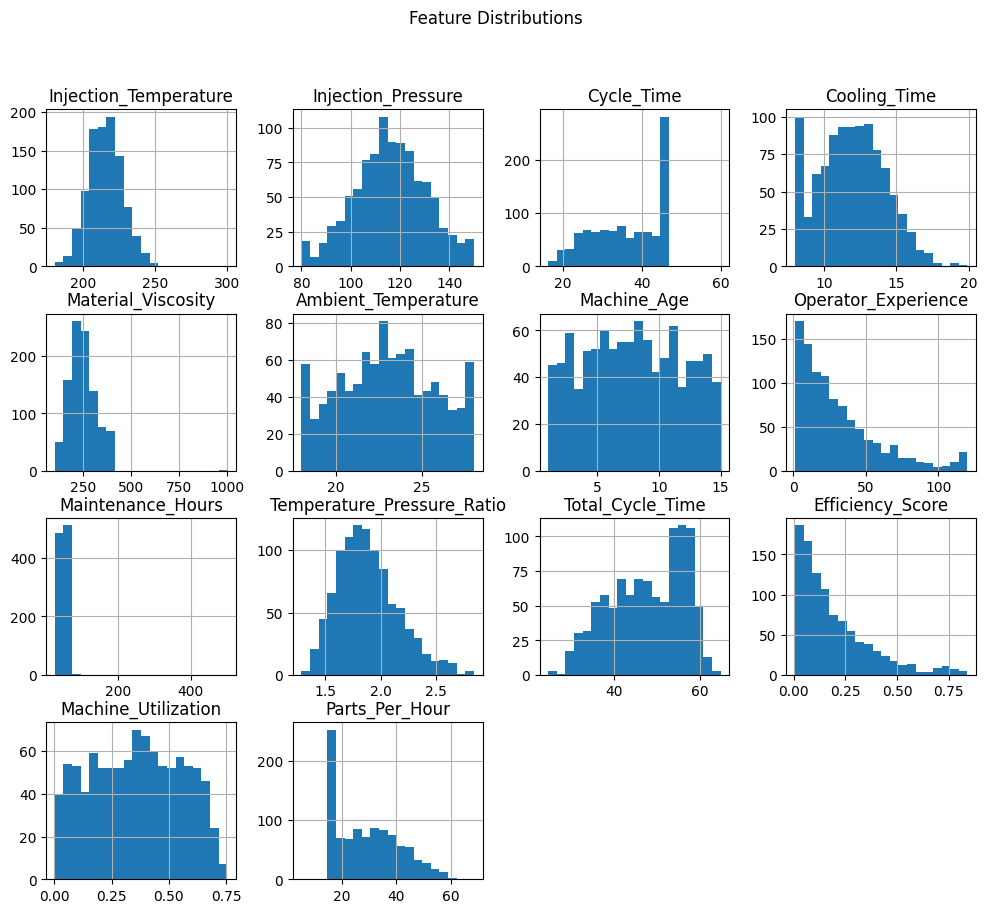

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64','int64'])

# Fill missing numeric values with mean
numeric_df = numeric_df.fillna(numeric_df.mean())

# 1. Histograms
numeric_df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

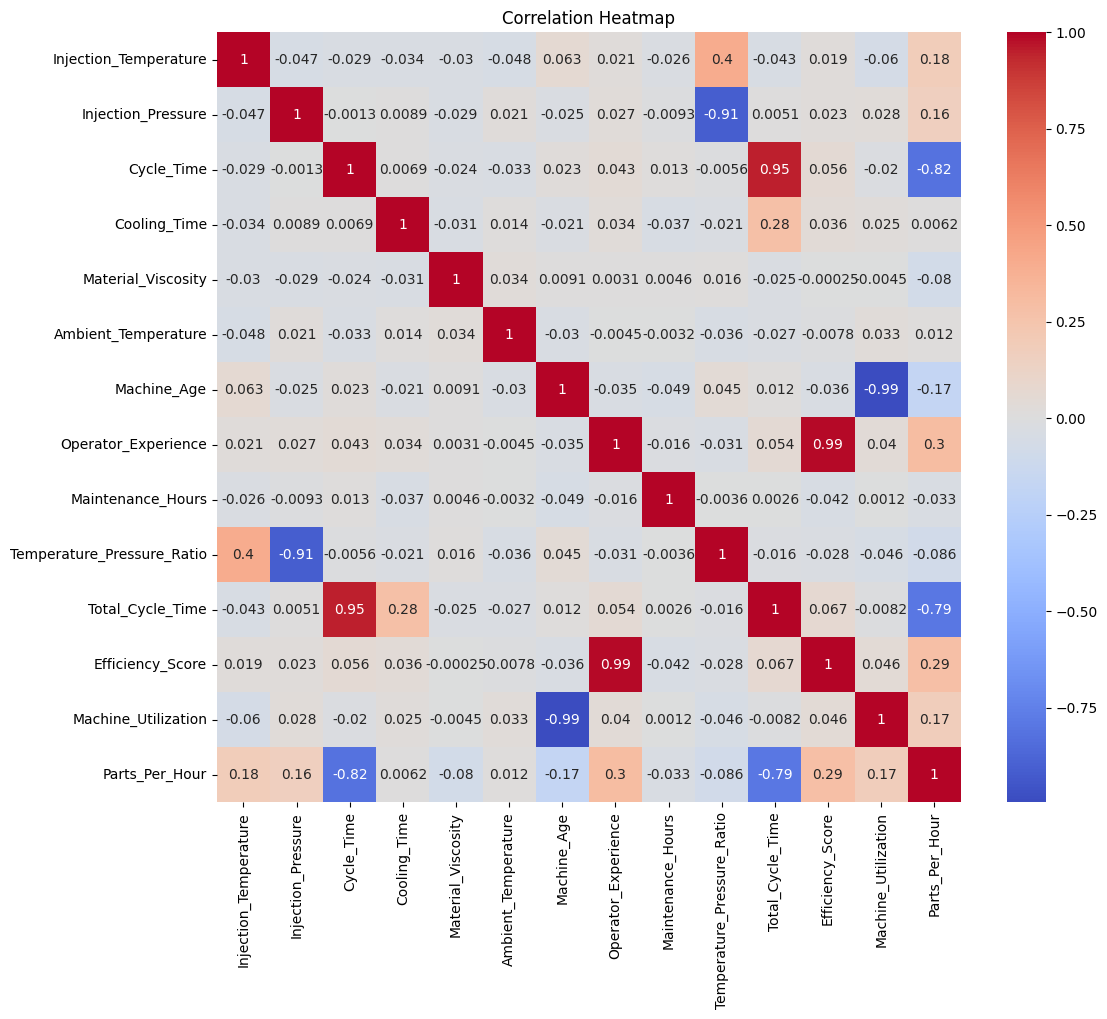

In [ ]:
# 2. Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

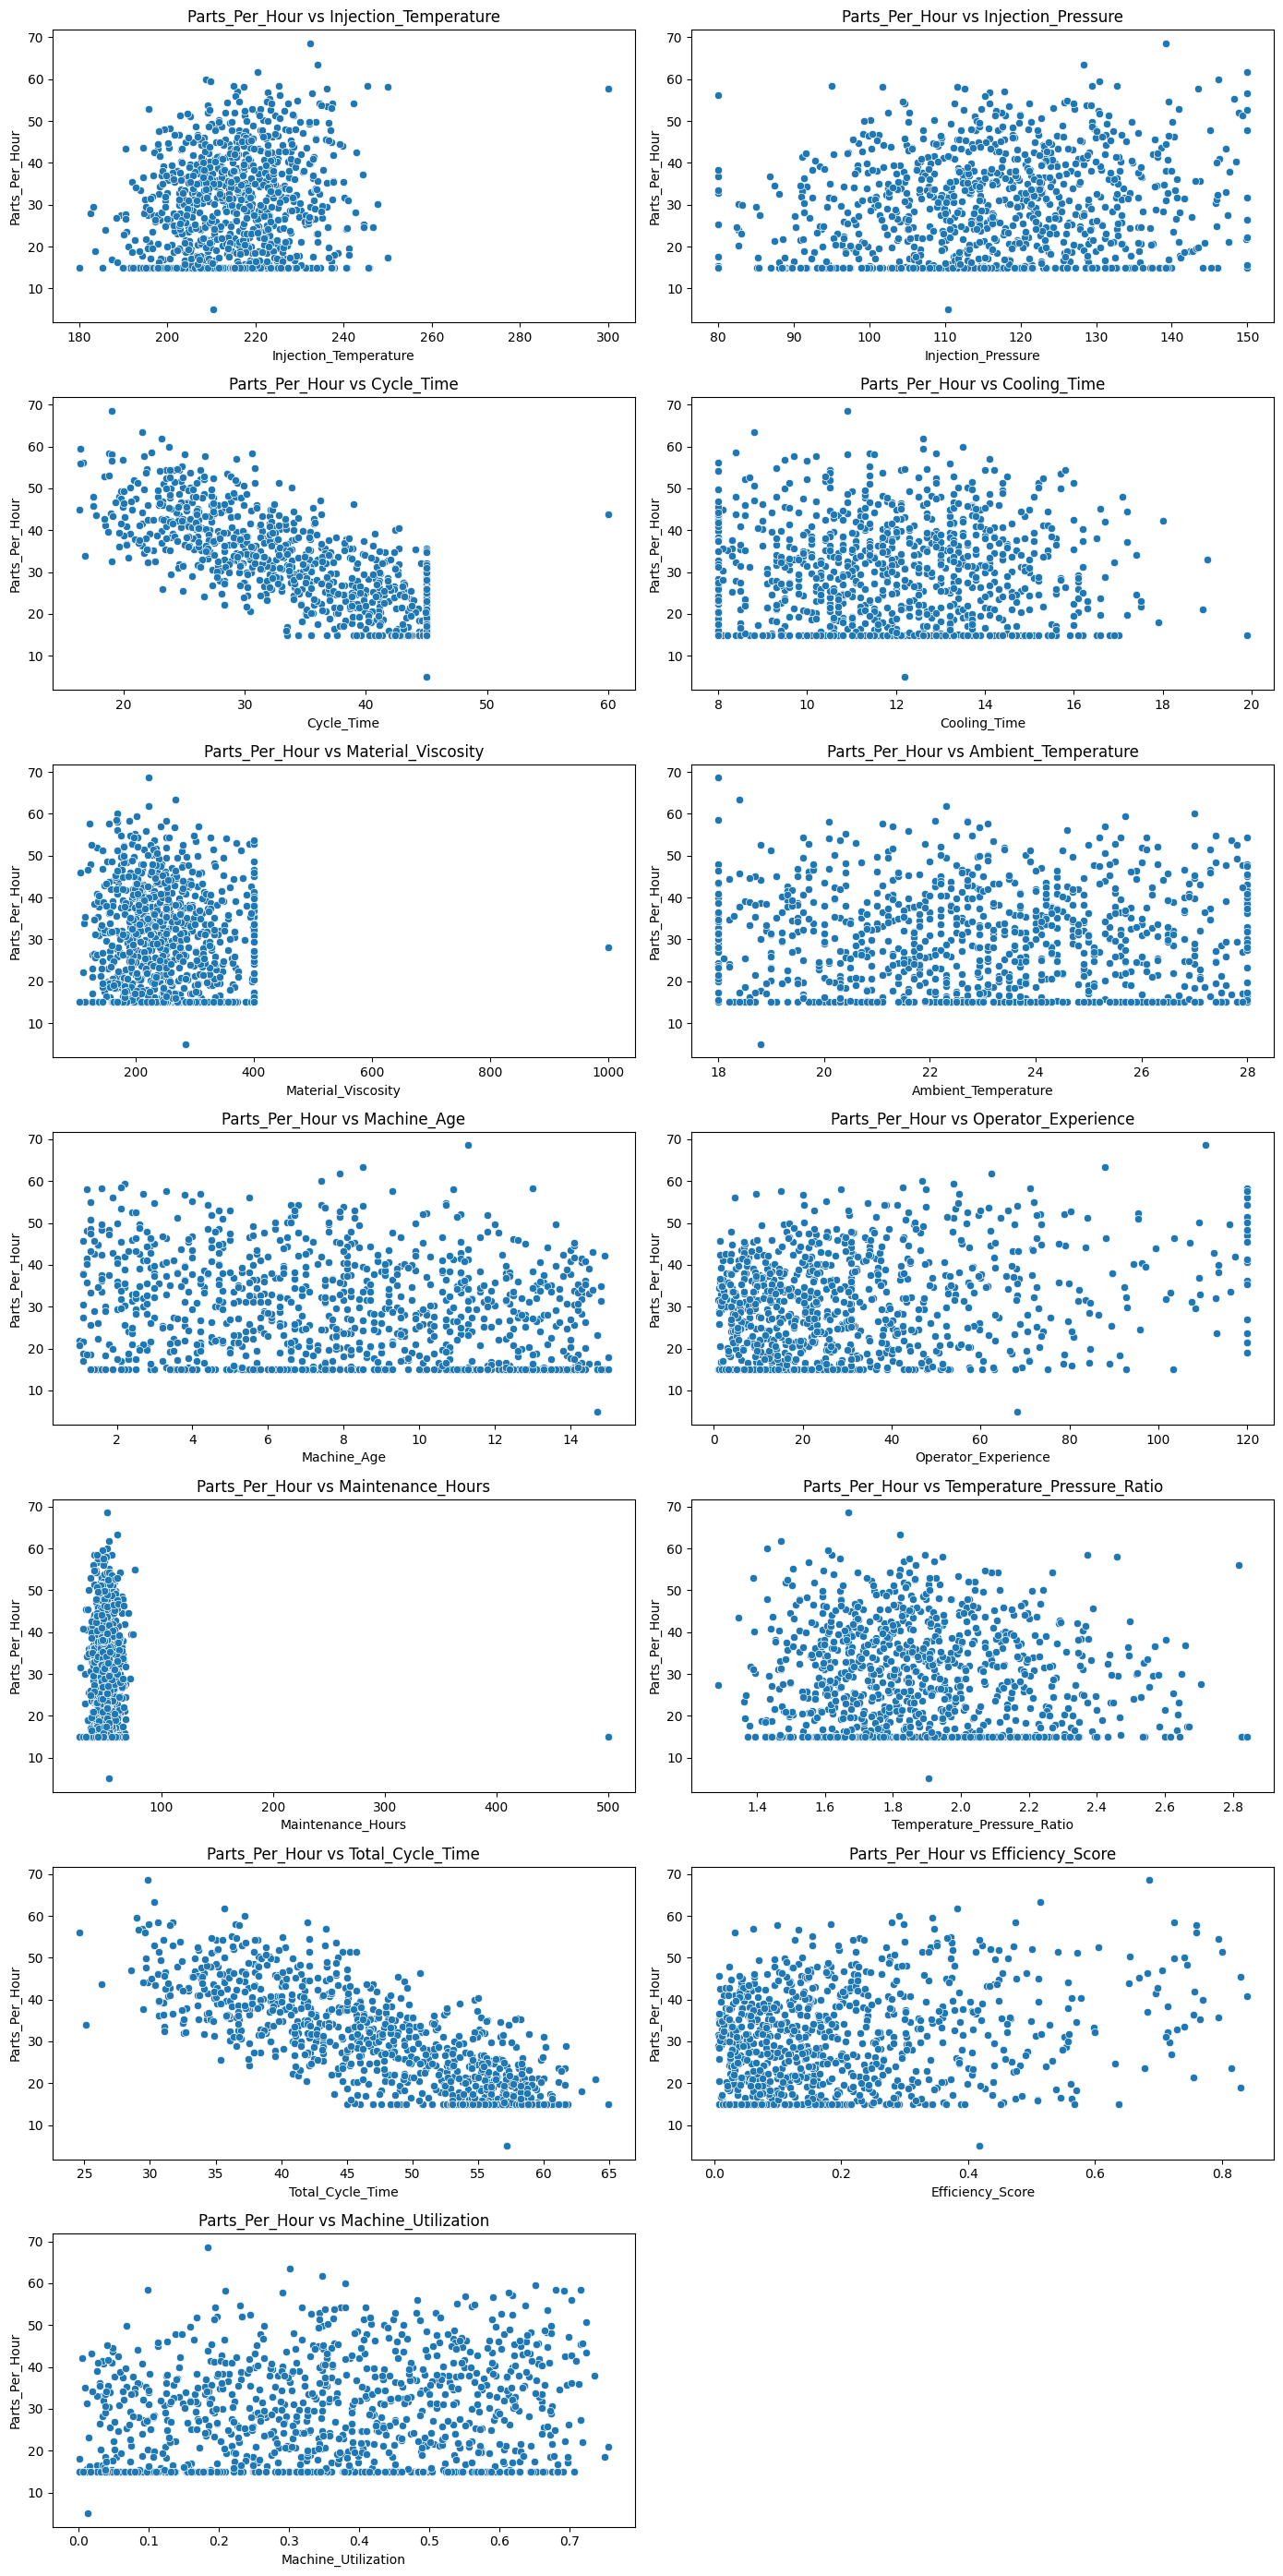

In [ ]:
# 3. Scatter plots (rows x columns) for target vs features
target = 'Parts_Per_Hour'
features = [col for col in numeric_df.columns if col != target]

rows = (len(features) + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=numeric_df[col], y=numeric_df[target], ax=axes[i])
    axes[i].set_title(f"{target} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# Remove empty axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = numeric_df.drop(target, axis=1)
y = numeric_df[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

MSE: 20.05, RMSE: 4.48, MAE: 3.54, R2: 0.85


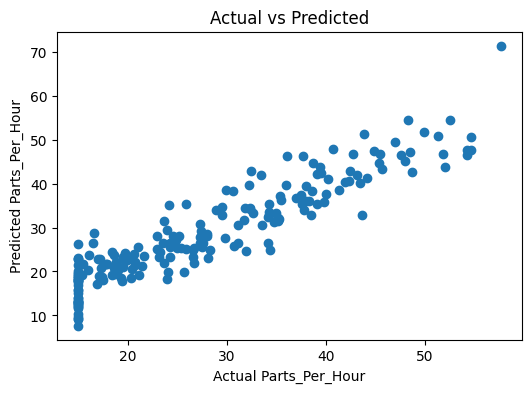

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

# Actual vs Predicted plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Parts_Per_Hour")
plt.ylabel("Predicted Parts_Per_Hour")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import os
import pickle

# Make sure the folder exists
os.makedirs("Model", exist_ok=True)

# Save the trained Linear Regression model
with open("Model/linear_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save the scaler
with open("Model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
from google.colab import files

files.download('/content/Model/linear_regression_model.pkl')
files.download('/content/Model/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>